In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2",
                                   output_hidden_states=True)
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6539.86it/s]

Ready!


In [2]:
# Can vs Can't sentences
can_sentences = [
    "I can run very fast",
    "She can speak three languages",
    "He can solve difficult problems",
    "They can finish the work today",
    "We can help you with this",
    "The dog can jump very high",
    "I can cook delicious meals",
    "She can play the piano beautifully",
    "He can swim across the river",
    "They can build amazing things",
]

cant_sentences = [
    "I can't run very fast",
    "She can't speak three languages",
    "He can't solve difficult problems",
    "They can't finish the work today",
    "We can't help you with this",
    "The dog can't jump very high",
    "I can't cook delicious meals",
    "She can't play the piano beautifully",
    "He can't swim across the river",
    "They can't build amazing things",
]

all_sentences = can_sentences + cant_sentences
all_labels    = [1]*10 + [0]*10  # 1=can, 0=can't

print(f"Total sentences: {len(all_sentences)}")
print(f"Can:     {sum(all_labels)}")
print(f"Can't:   {len(all_labels) - sum(all_labels)}")

Total sentences: 20
Can:     10
Can't:   10


In [3]:
def get_sentence_embedding(text, layer_idx=-1):
    inputs = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.hidden_states[layer_idx][0].mean(dim=0).numpy()

print("Logistic Regression per Layer:")
print(f"\n{'Layer':<10} {'Accuracy'}")
print("-"*25)

layer_accs = []

for layer_idx in range(13):
    X = np.array([get_sentence_embedding(s, layer_idx) 
                  for s in all_sentences])
    y = np.array(all_labels)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    acc = accuracy_score(y_test, lr.predict(X_test))
    layer_accs.append(acc)
    
    label = "Emb" if layer_idx == 0 else f"L{layer_idx}"
    print(f"{label:<10} {acc*100:.1f}%")

print(f"\nBest layer: L{np.argmax(layer_accs)} "
      f"({max(layer_accs)*100:.1f}%)")

Logistic Regression per Layer:

Layer      Accuracy
-------------------------
Emb        100.0%
L1         100.0%
L2         100.0%
L3         100.0%
L4         100.0%
L5         100.0%
L6         100.0%
L7         100.0%
L8         100.0%
L9         100.0%
L10        100.0%
L11        100.0%
L12        83.3%

Best layer: L0 (100.0%)


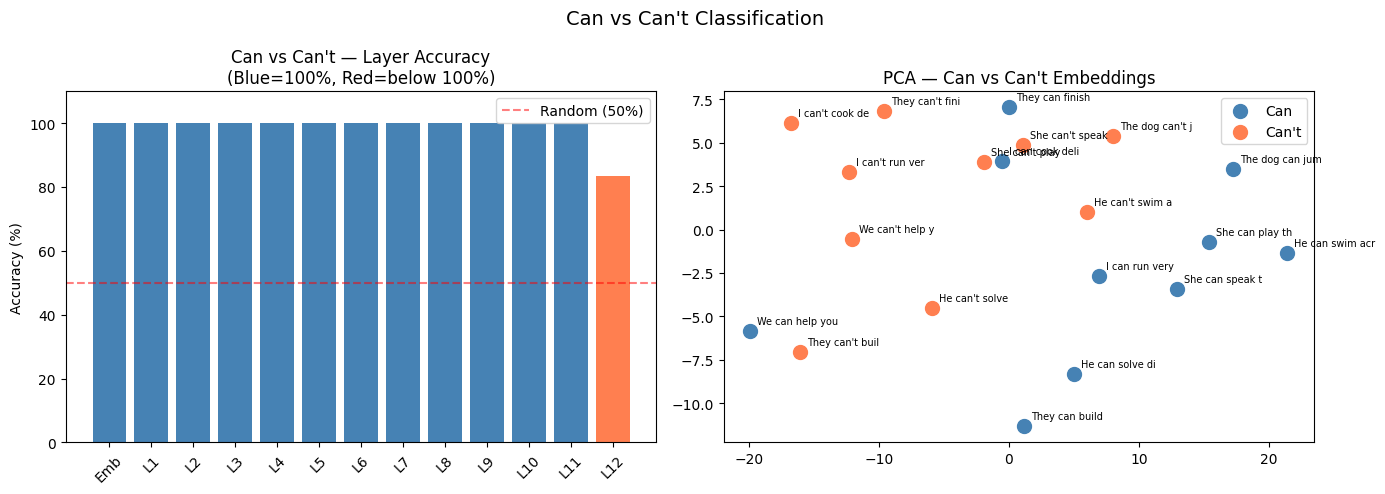

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x       = range(13)
xlabels = ["Emb"] + [f"L{i}" for i in range(1, 13)]
colors  = ["steelblue" if a == 1.0 else "coral" 
           for a in layer_accs]

axes[0].bar(x, [a*100 for a in layer_accs], color=colors)
axes[0].axhline(y=50, color="red", linestyle="--",
                alpha=0.5, label="Random (50%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(xlabels, rotation=45)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Can vs Can't — Layer Accuracy\n"
                  "(Blue=100%, Red=below 100%)")
axes[0].set_ylim(0, 110)
axes[0].legend()

# PCA visualization — last layer
from sklearn.decomposition import PCA

X_last = np.array([get_sentence_embedding(s, -1) 
                   for s in all_sentences])
pca    = PCA(n_components=2)
X_2d   = pca.fit_transform(X_last)

axes[1].scatter(X_2d[:10, 0],  X_2d[:10, 1],
                color="steelblue", s=100, label="Can")
axes[1].scatter(X_2d[10:, 0],  X_2d[10:, 1],
                color="coral",     s=100, label="Can't")

for i, sentence in enumerate(all_sentences):
    axes[1].annotate(sentence[:15],
                    (X_2d[i, 0], X_2d[i, 1]),
                    textcoords="offset points",
                    xytext=(5, 5), fontsize=7)

axes[1].set_title("PCA — Can vs Can't Embeddings")
axes[1].legend()

plt.suptitle("Can vs Can't Classification", fontsize=14)
plt.tight_layout()
plt.show()


* GPT-2 perfectly understands negation (e.g., “can” vs. “can’t”).
* Almost all layers achieve 100% accuracy.
* In PCA, the two groups form clearly separate clusters.
* Even a single-word difference is captured by GPT-2.
